In [ ]:
pip install numpy pandas

In [17]:
pip uninstall numpy

In [ ]:
import pandas as pd # type: ignore
import matplotlib as plt  # type: ignore
import seaborn as sns # type: ignore
from sklearn.model_selection import train_test_split, GridSearchCV # type: ignore
from sklearn.metrics import mean_squared_error, r2_score # type: ignore
import os
import joblib # type: ignore


In [ ]:
dr = pd.read_excel('descriptors.xlsx')
del dr['ID']
dr.head()


In [ ]:
df = pd.read_csv("Morgan.csv")
del df['ID']
df.head()

In [ ]:
def split_bits(row):
    if pd.isna(row['morgan_fingerprint']):
        return pd.Series([np.nan] * 1024)  
    else:
        return pd.Series(list(row['morgan_fingerprint']))

bit_columns = df.apply(split_bits, axis=1)

bit_columns.columns = [f'F_{i+1}' for i in range(bit_columns.shape[1])]
final_df = pd.concat([df.reset_index(drop=True), bit_columns], axis=1)
final_df.head()

In [ ]:
final_df = final_df.dropna()

y1 = dr[dr['smiles'].isin(final_df['smiles'])]

In [65]:
input = final_df.copy()
del input['morgan_fingerprint']
del input['smiles']
input.head()

,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,F_9,F_10,...,F_1015,F_1016,F_1017,F_1018,F_1019,F_1020,F_1021,F_1022,F_1023,F_1024
0,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [66]:
del y1['smiles']

In [67]:
y1.head()

,vmin_vmin_boltz,vmin_r_boltz,fmo_e_homo_boltz,fmo_e_lumo_boltz,fmo_mu_boltz,fmo_eta_boltz,fmo_omega_boltz,somo_ra_boltz,somo_rc_boltz,nbo_P_boltz,...,sterimol_burB5_boltz,sterimol_burB5_min,sterimol_burB5_max,sterimol_burB5_delta,sterimol_burB5_vburminconf,sterimol_burL_boltz,sterimol_burL_min,sterimol_burL_max,sterimol_burL_delta,sterimol_burL_vburminconf
0,-0.061654,1.819048,-0.218243,-0.025112,-0.121678,0.193131,0.038336,0.059115,-0.363712,0.801914,...,7.439480,6.306577,7.835474,1.528897,7.262693,7.291573,7.106519,8.238802,1.132283,7.735548
1,-0.063670,1.784157,-0.206310,-0.023277,-0.114794,0.183033,0.036033,0.061658,-0.345264,0.816302,...,6.572514,6.339063,7.850955,1.511892,6.407769,7.285463,6.908743,8.216943,1.308200,7.992698
2,-0.066303,1.798595,-0.213323,-0.016923,-0.115123,0.196400,0.033750,0.069846,-0.356952,0.796412,...,7.156276,6.349086,7.287324,0.938238,7.021625,7.306643,7.025374,8.361404,1.336030,7.424874
3,-0.067319,1.795292,-0.211571,-0.013802,-0.112687,0.197770,0.032124,0.070775,-0.349017,0.798225,...,7.238774,6.369287,7.813010,1.443723,7.653520,7.338674,6.996319,8.333428,1.337110,7.483233
4,-0.061351,1.816461,-0.218842,-0.030145,-0.124494,0.188697,0.041069,0.060353,-0.376125,0.787516,...,6.497622,6.092458,7.055260,0.962802,6.376705,7.370445,7.021018,8.155038,1.134020,8.086289


In [68]:
y1.head()

,vmin_vmin_boltz,vmin_r_boltz,fmo_e_homo_boltz,fmo_e_lumo_boltz,fmo_mu_boltz,fmo_eta_boltz,fmo_omega_boltz,somo_ra_boltz,somo_rc_boltz,nbo_P_boltz,...,sterimol_burB5_boltz,sterimol_burB5_min,sterimol_burB5_max,sterimol_burB5_delta,sterimol_burB5_vburminconf,sterimol_burL_boltz,sterimol_burL_min,sterimol_burL_max,sterimol_burL_delta,sterimol_burL_vburminconf
0,-0.061654,1.819048,-0.218243,-0.025112,-0.121678,0.193131,0.038336,0.059115,-0.363712,0.801914,...,7.439480,6.306577,7.835474,1.528897,7.262693,7.291573,7.106519,8.238802,1.132283,7.735548
1,-0.063670,1.784157,-0.206310,-0.023277,-0.114794,0.183033,0.036033,0.061658,-0.345264,0.816302,...,6.572514,6.339063,7.850955,1.511892,6.407769,7.285463,6.908743,8.216943,1.308200,7.992698
2,-0.066303,1.798595,-0.213323,-0.016923,-0.115123,0.196400,0.033750,0.069846,-0.356952,0.796412,...,7.156276,6.349086,7.287324,0.938238,7.021625,7.306643,7.025374,8.361404,1.336030,7.424874
3,-0.067319,1.795292,-0.211571,-0.013802,-0.112687,0.197770,0.032124,0.070775,-0.349017,0.798225,...,7.238774,6.369287,7.813010,1.443723,7.653520,7.338674,6.996319,8.333428,1.337110,7.483233
4,-0.061351,1.816461,-0.218842,-0.030145,-0.124494,0.188697,0.041069,0.060353,-0.376125,0.787516,...,6.497622,6.092458,7.055260,0.962802,6.376705,7.370445,7.021018,8.155038,1.134020,8.086289


In [73]:
for column in input.columns:
    if input[column].dtype == 'object':
        input[column] = pd.to_numeric(input[column], errors='coerce')

# Check the new data types
print(input.dtypes)

F_1       int64
F_2       int64
F_3       int64
F_4       int64
F_5       int64
          ...  
F_1020    int64
F_1021    int64
F_1022    int64
F_1023    int64
F_1024    int64
Length: 1024, dtype: object


LASSO + LINEAR

In [ ]:
import os
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X = input  # Your input DataFrame
Y = y1.copy()  # Your target DataFrame
models = {}
results_list = []

# Create a directory to save models
os.makedirs('models', exist_ok=True)

# Define the parameter grid for GridSearchCV
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100],  # Regularization strength for Lasso
}

# Loop through each feature in the target DataFrame
for feature in Y.columns:
    y = Y[feature]

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Initialize the Lasso model
    lasso_model = Lasso()

    # Set up GridSearchCV
    grid_search = GridSearchCV(estimator=lasso_model, param_grid=param_grid,
                               scoring='neg_mean_squared_error', cv=3, n_jobs=-1, verbose=1)

    # Fit the model using GridSearchCV
    grid_search.fit(X_train, y_train)

    # Best model after grid search
    best_model = grid_search.best_estimator_

    # Predict on the test set
    y_pred = best_model.predict(X_test)

    # Calculate R² and RMSE
    r2 = r2_score(y_test, y_pred) if len(set(y_test)) > 1 else 0
    rmse = mean_squared_error(y_test, y_pred, squared=False)

    # Store the results
    results_list.append({'Feature': feature, 'R²': r2, 'RMSE': rmse})
    models[feature] = best_model

    # Save the best model
    joblib.dump(best_model, f'models/model_{feature}.joblib')

# Create a DataFrame for results and save to CSV
results_df = pd.DataFrame(results_list)
results_df.to_csv('model_performance.csv', index=False)

print("Model performance metrics saved to 'model_performance.csv'")
print("Models saved in the 'models' directory.")


VISUALIZATION

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('model_performance_lasso.csv') #file path for csv or excel 



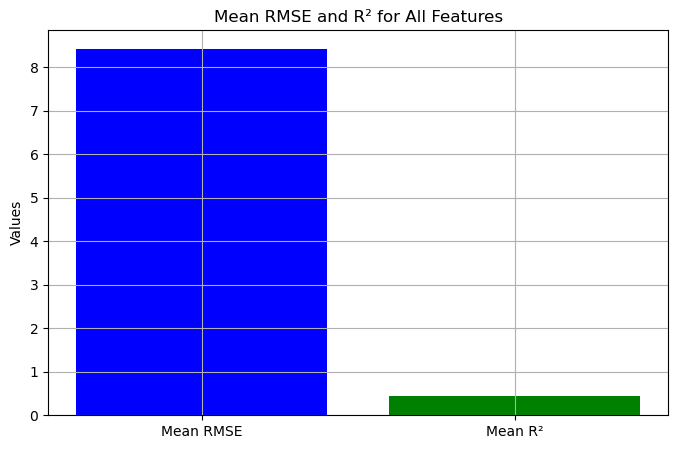

0.45167961041361254


In [31]:
mean_rmse = data['RMSE'].mean()
mean_r2 = data['R2'].mean()

plt.figure(figsize=(8, 5))
plt.bar(['Mean RMSE', 'Mean R²'], [mean_rmse, mean_r2], color=['blue', 'green'])
plt.title('Mean RMSE and R² for All Features')
plt.ylabel('Values')
plt.grid()
plt.show()
print(mean_r2)